# SOS Lyapunov Search with SumOfSquares.jl

Search for a **polynomial Lyapunov function** $V(x)$ certifying **global asymptotic stability** (GAS) at the origin for a polynomial vector field $\dot{x} = f(x)$.

The SDP encodes two constraints:

| # | Condition | Implies |
|---|-----------|---------|
| 1 | $V(x) - \varepsilon \lVert x \rVert^2 \in P_{SOS(d)}$ | $V$ is positive definite and radially unbounded |
| 2 | $-\dot{V}(x) - \varepsilon \lVert x \rVert^2 \in P_{SOS(d)}$ | $\dot{V}$ is negative definite |

where $P_{SOS(d)}$ denotes the cone of sum-of-squares polynomials and $d = \deg(V)/2$.

In [ ]:
using JuMP
using SumOfSquares
using DynamicPolynomials
using SCS # Semidefinite programming solver
# using CSDP # Alternative SDP solver (uncomment if you want to try it)
include("SOSLyap.jl");

In [302]:
# The main function to solve for the SOS Lyapunov function
function SolveSOSLyapunov(x, f; gamma = 0.001, d = 2, verbose = false)
    # 1. Set up the SOS model with the chosen SDP solver
    model = SOSModel(SCS.Optimizer)
    # model = SOSModel(CSDP.Optimizer)
    if !verbose
        set_silent(model) # Suppresses verbose solver output
    end

    # 2. Define the candidate Lyapunov function V(x)
    # We want V(0) = 0, so we create monomials of degree 1 to 2*d (omitting the constant term)
    monos = monomials(x, 2:(2*d))
    # @variable(model, V, Poly(monos))
    @variable(model, c[1:length(monos)])
    V = polynomial(c, monos)

    # 3. Epsilon constraints to enforce strict positivity
    # Create a matrix of coefficients for the even monomials (x[i]^2, x[i]^4, etc.) to ensure we have a positive definite term
    @variable(model, coeffs[1:length(x), 1:d] >= 0) # Coefficients for x[i]^(2*k) terms
    for i in 1:length(x)
        @constraint(model, sum(coeffs[i, k] for k in 1:d) >= gamma) # Enforce positive coefficients
    end

    # 3. Enforce strict positive definiteness of V(x)
    # V(x) - gamma * ||x||^2 is Sum of Squares (SOS)
    @constraint(model, V - sum(coeffs[i, k] * x[i]^(2*k) for i in 1:length(x), k in 1:d) >= 0)

    # 4. Calculate the Lie derivative dV/dt along the system trajectories
    dV = sum(differentiate(V, x[i]) * f[i] for i in 1:length(x))

    # 5 Epsilon constraints to enforce strict negativity of dV/dt
    # Same as in step 3
    @variable(model, dotcoeffs[1:length(x), 1:d] >= 0) # Coefficients for x[i]^(2*k) terms
    for i in 1:length(x)
        @constraint(model, sum(dotcoeffs[i, k] for k in 1:d) >= gamma) # Enforce positive coefficients
    end

    # 6. Enforce strict negative definiteness of dV/dt
    # -dV/dt is Sum of Squares (SOS)
    @constraint(model, -dV - gamma * sum(dotcoeffs[i, k] * x[i]^(2*k) for i in 1:length(x), k in 1:d) >= 0)

    # ==========================================
    # (optional) Implementing an L1 norm objective to encourage sparsity in the coefficients of V
    # ==========================================
    # # Introduce slack variables 't' bounded below by 0
    # @variable(model, t[1:length(c)] >= 0)
    
    # # Constrain the slack variables to bound the coefficients
    # for i in 1:length(c)
    #     @constraint(model, c[i] <= t[i])
    #     @constraint(model, c[i] >= -t[i])
    # end
    
    # # Set the objective to minimize the sum of the slack variables
    # @objective(model, Min, sum(t))
    # ==========================================

    # 7. Solve the Semidefinite Program (SDP)
    optimize!(model)

    # 8. Output the results
    if termination_status(model) == MOI.OPTIMAL
        println("A valid Lyapunov function was found!")
        return value(V)
    else
        println("The solver could not find a valid Lyapunov function. Status: ", termination_status(model))
        return nothing
    end

end 

SolveSOSLyapunov (generic function with 1 method)

# Example 1:
$$
    \dot x =f(x_1,x_2)= \begin{bmatrix}-x_1 + x_2^3 \\ -x_1\end{bmatrix}
$$

In [304]:
# Define the polynomial variables
@polyvar x[1:2]

# Vector field  ẋ = f(x)
f = [
    -x[1] + x[2]^3,   # ẋ₁
    -x[1],   # ẋ₂
]

# Solve for the Lyapunov function
V_val = SolveSOSLyapunov(x, f; gamma = 1.0, d = 2, verbose = false)
V_rounded = DynamicPolynomials.map_coefficients(c -> round(c, digits=3), (V_val).*(1)) # Multiply times appropriate scaling factor for cleaner output
V_rounded

A valid Lyapunov function was found!


0.73x₂² - 1.46x₁x₂ + 2.336x₁² + 1.182x₂⁴

In [ ]:
# Playing around with the solution we can find a simple polynomial that is Lyapunov function
# (The verifyLyapunov function is defined in SOSLyap.jl)
V_simple = 6*x[1]^2 - 2*x[1]*x[2] + 1*x[2]^2 + 3*x[2]^4
verifyLyapunov(V_simple, x, f)

Verification successful: V is a valid Lyapunov function.


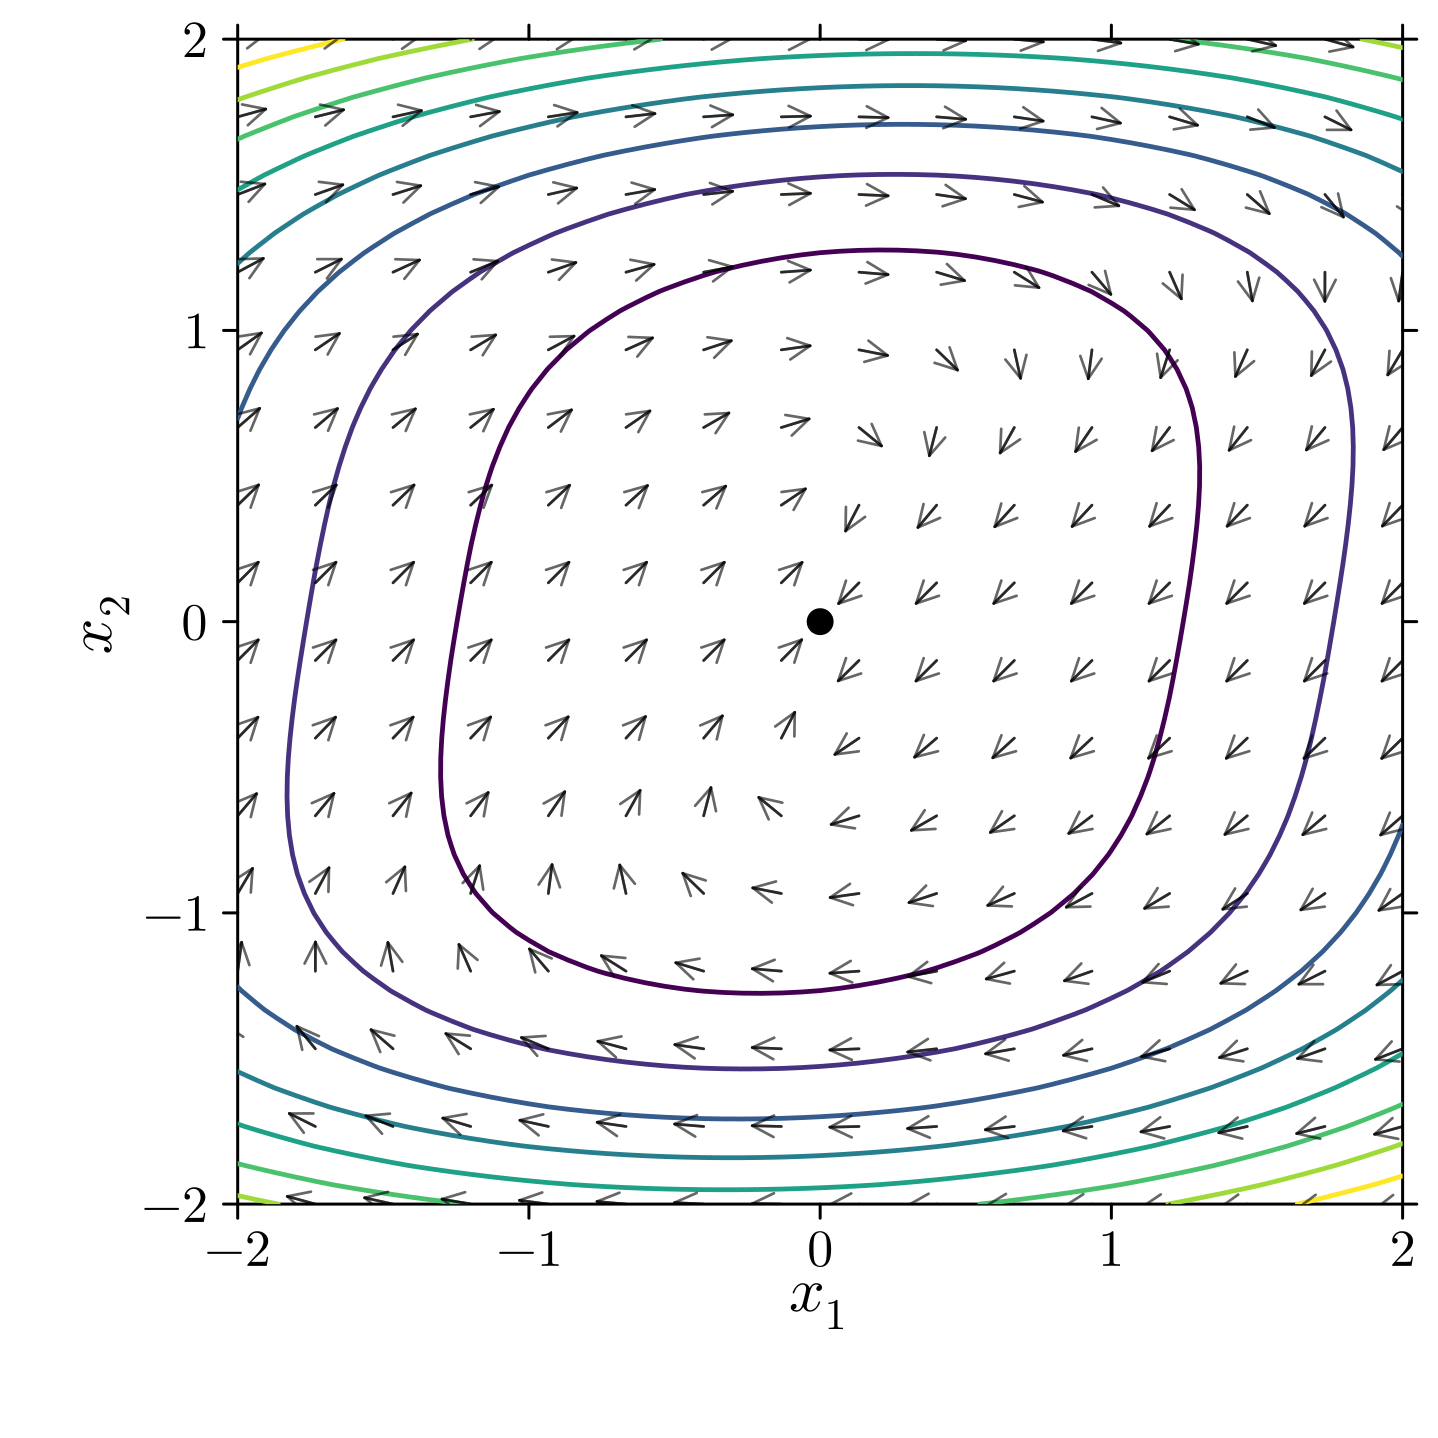

In [306]:
# Plot the level sets of the Lyapunov function and the vector field
p = planeLyapunovLevelsAndVectorField(V_simple, (x,y)-> (-x+y^3), (x,y)-> (-x))

# Save the plot
savefig(p, "lyapunov_plot.png")
p

# Example 2
This example is a $4$ dimensional system 
$$
    \dot x = \begin{bmatrix}
        -x_1+x_2^3-3x_3x_4 \\
        -x_1+x_2^3 \\
        x_1x_4-x_3 \\
        x_1x_3-x_4^3
    \end{bmatrix}
$$
It is not easy to determine by inspection that the system is stable. 

In [292]:
# Define the polynomial variables
@polyvar x[1:4]

# Define the polynomial vector field: dx/dt = f(x)
# Example system: globally asymptotically stable at the origin

# Vector field  ẋ = f(x)
f = [
    -x[1] + x[2]^3 - 3*x[3]*x[4],   # ẋ₁
    -x[1]-x[2]^3,   # ẋ₂
    x[1]*x[4]-x[3],   # ẋ₃
    x[1]*x[3]-x[4]^3,   # ẋ₄
]

# Solve for the Lyapunov function
V_val = SolveSOSLyapunov(x, f; gamma = 1., d=2)
V_rounded = DynamicPolynomials.map_coefficients(c -> round(c, digits=5), (V_val)) # Multiply times appropriate scaling factor for cleaner output
V_rounded

A valid Lyapunov function was found!


1.84932x₄² + 2.08509x₃² + 0.30097x₂² - 0.60195x₁x₂ + 1.88126x₁² + 0.28646x₂x₃x₄ - 0.34548x₁x₃x₄ + 0.2019x₄⁴ + 0.1022x₃²x₄² + 0.11618x₃⁴ + 0.06909x₂²x₄² + 0.33423x₂²x₃² + 0.97439x₂⁴ + 0.00172x₁x₂x₄² + 0.22304x₁x₂x₃² + 0.03888x₁x₂³ + 0.09706x₁²x₄² + 0.11152x₁²x₃² + 0.35242x₁²x₂² + 0.13905x₁³x₂ + 0.03476x₁⁴

In [293]:
verifyLyapunov(V_rounded, x, f)

Verification successful: V is a valid Lyapunov function.
